# **Cellule 1 — Imports**

In [ ]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

# **Cellule 2 —  device**

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


# **Cellule 3 — Chargement de MNIST**

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.85 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

Train: 51000
Val  : 9000
Test : 10000


# **Cellule 4 — Visualisation rapide de quelques images**

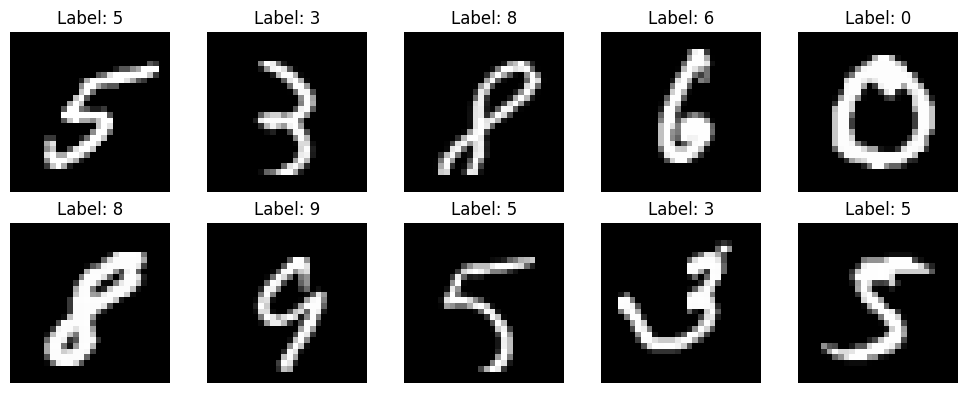

In [ ]:
classes = [str(i) for i in range(10)]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# **Cellule 5 — Pourquoi un MLP est peu adapté aux images**

In [ ]:
sample_img = images[0]
print("Taille image :", sample_img.shape)   # [1, 28, 28]
print("Taille image aplatie pour MLP :", sample_img.numel())

Taille image : torch.Size([1, 28, 28])
Taille image aplatie pour MLP : 784


# **Cellule 6 — Corrélation croisée 2D manuelle**

In [ ]:
def corr2d(X, K, stride=1, padding=0):
    if padding > 0:
        X = np.pad(X, ((padding, padding), (padding, padding)), mode='constant')

    h, w = K.shape
    out_h = (X.shape[0] - h) // stride + 1
    out_w = (X.shape[1] - w) // stride + 1

    Y = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = X[i*stride:i*stride+h, j*stride:j*stride+w]
            Y[i, j] = np.sum(region * K)

    return Y

# **Cellule 7 — Max-pooling et average-pooling manuels**

In [ ]:
def max_pool2d_manual(X, pool_size=2, stride=2):
    h = pool_size
    w = pool_size
    out_h = (X.shape[0] - h) // stride + 1
    out_w = (X.shape[1] - w) // stride + 1
    Y = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = X[i*stride:i*stride+h, j*stride:j*stride+w]
            Y[i, j] = np.max(region)

    return Y

def avg_pool2d_manual(X, pool_size=2, stride=2):
    h = pool_size
    w = pool_size
    out_h = (X.shape[0] - h) // stride + 1
    out_w = (X.shape[1] - w) // stride + 1
    Y = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = X[i*stride:i*stride+h, j*stride:j*stride+w]
            Y[i, j] = np.mean(region)

    return Y

# **Cellule 8 — Test manuel sur une image simple**

In [ ]:
X_small = np.array([
    [0, 1, 2, 3],
    [1, 2, 3, 4],
    [2, 3, 4, 5],
    [3, 4, 5, 6]
], dtype=np.float32)

K = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

print("Image X:\n", X_small)
print("\nKernel K:\n", K)

Y_corr = corr2d(X_small, K, stride=1, padding=0)
print("\nCorrélation croisée manuelle:\n", Y_corr)

Y_max = max_pool2d_manual(X_small, pool_size=2, stride=2)
print("\nMax pooling manuel:\n", Y_max)

Y_avg = avg_pool2d_manual(X_small, pool_size=2, stride=2)
print("\nAverage pooling manuel:\n", Y_avg)

Image X:
 [[0. 1. 2. 3.]
 [1. 2. 3. 4.]
 [2. 3. 4. 5.]
 [3. 4. 5. 6.]]

Kernel K:
 [[ 1.  0.]
 [ 0. -1.]]

Corrélation croisée manuelle:
 [[-2. -2. -2.]
 [-2. -2. -2.]
 [-2. -2. -2.]]

Max pooling manuel:
 [[2. 4.]
 [4. 6.]]

Average pooling manuel:
 [[1. 3.]
 [3. 5.]]


# **Cellule 9 — Comparaison avec PyTorch**

In [ ]:
X_torch = torch.tensor(X_small).unsqueeze(0).unsqueeze(0)  # [1,1,4,4]
K_torch = torch.tensor(K).unsqueeze(0).unsqueeze(0)        # [1,1,2,2]

conv_result = F.conv2d(X_torch, K_torch, stride=1, padding=0)
max_result = F.max_pool2d(X_torch, kernel_size=2, stride=2)
avg_result = F.avg_pool2d(X_torch, kernel_size=2, stride=2)

print("Conv2d PyTorch:\n", conv_result.squeeze().numpy())
print("\nMaxPool2d PyTorch:\n", max_result.squeeze().numpy())
print("\nAvgPool2d PyTorch:\n", avg_result.squeeze().numpy())

Conv2d PyTorch:
 [[-2. -2. -2.]
 [-2. -2. -2.]
 [-2. -2. -2.]]

MaxPool2d PyTorch:
 [[2. 4.]
 [4. 6.]]

AvgPool2d PyTorch:
 [[1. 3.]
 [3. 5.]]


# **Cellule 10 — Calculs manuels de tailles de sortie**

In [ ]:
def conv_output_size(n, k, p=0, s=1):
    return ((n - k + 2*p) // s) + 1

def pool_output_size(n, k, s=None, p=0):
    if s is None:
        s = k
    return ((n - k + 2*p) // s) + 1

n = 28
print("Entrée 28x28")
print("Conv 5x5, padding=0, stride=1 ->", conv_output_size(n, 5, 0, 1))
print("Conv 5x5, padding=2, stride=1 ->", conv_output_size(n, 5, 2, 1))
print("Pooling 2x2, stride=2 ->", pool_output_size(24, 2, 2))

Entrée 28x28
Conv 5x5, padding=0, stride=1 -> 24
Conv 5x5, padding=2, stride=1 -> 28
Pooling 2x2, stride=2 -> 12


# **Cellule 11 — MLP simple pour images**

In [ ]:
class ImageMLP(nn.Module):
    def __init__(self, input_dim=28*28, num_classes=10):
        super(ImageMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# **Cellule 12 — CNN type LeNet configurable**

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_filters1=6, num_filters2=16, padding=0, stride=1, pooling_type="max", use_1x1=False):
        super(SimpleCNN, self).__init__()

        self.pooling_type = pooling_type
        self.use_1x1 = use_1x1

        self.conv1 = nn.Conv2d(1, num_filters1, kernel_size=5, stride=stride, padding=padding)
        self.conv2 = nn.Conv2d(num_filters1, num_filters2, kernel_size=5, stride=1, padding=0)

        if use_1x1:
            self.conv1x1 = nn.Conv2d(num_filters2, num_filters2, kernel_size=1)

        with torch.no_grad():
            x = torch.zeros(1, 1, 28, 28)
            x = self._forward_features(x)
            flatten_dim = x.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flatten_dim, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def pool(self, x):
        if self.pooling_type == "max":
            return F.max_pool2d(x, 2)
        elif self.pooling_type == "avg":
            return F.avg_pool2d(x, 2)
        else:
            raise ValueError("pooling_type doit être 'max' ou 'avg'")

    def _forward_features(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))

        if self.use_1x1:
            x = F.relu(self.conv1x1(x))

        x = self.pool(x)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# **Cellule 13 — Fonction d’évaluation**

In [ ]:
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, average="macro")
    rec = recall_score(all_targets, all_preds, average="macro")
    f1 = f1_score(all_targets, all_preds, average="macro")
    cm = confusion_matrix(all_targets, all_preds)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
        "y_true": all_targets,
        "y_pred": all_preds
    }

# **Cellule 14 — Fonction d’entraînement**

In [ ]:
def train_model(model, train_loader, val_loader, device, epochs=5, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_running_loss += loss.item() * X_batch.size(0)

        val_loss = val_running_loss / len(val_loader.dataset)
        val_metrics = evaluate_model(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_metrics["accuracy"])

        if val_metrics["accuracy"] > best_acc:
            best_acc = val_metrics["accuracy"]
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f}"
        )

    model.load_state_dict(best_model_wts)
    return model, history, best_acc

# **Cellule 15 — Expérience MLP**

In [ ]:
mlp_model = ImageMLP()
mlp_model, mlp_history, mlp_best_val_acc = train_model(
    mlp_model, train_loader, val_loader, device, epochs=5, lr=0.001
)

mlp_test_metrics = evaluate_model(mlp_model, test_loader, device)

print("=== MLP Test Metrics ===")
print(mlp_test_metrics)

Epoch [1/5] | Train Loss: 0.3114 | Val Loss: 0.1624 | Val Acc: 0.9513
Epoch [2/5] | Train Loss: 0.1222 | Val Loss: 0.1239 | Val Acc: 0.9632
Epoch [3/5] | Train Loss: 0.0802 | Val Loss: 0.0981 | Val Acc: 0.9713
Epoch [4/5] | Train Loss: 0.0583 | Val Loss: 0.0895 | Val Acc: 0.9726
Epoch [5/5] | Train Loss: 0.0423 | Val Loss: 0.0845 | Val Acc: 0.9764
=== MLP Test Metrics ===
{'accuracy': 0.9777, 'precision': 0.9776083641509619, 'recall': 0.9775942631979835, 'f1': 0.9775777236354839, 'confusion_matrix': array([[ 971,    1,    0,    0,    0,    1,    3,    0,    3,    1],
       [   0, 1121,    2,    2,    0,    0,    2,    2,    6,    0],
       [   3,    0, 1009,    7,    1,    0,    1,    5,    6,    0],
       [   0,    0,    6,  989,    0,    3,    1,    3,    5,    3],
       [   2,    0,    3,    0,  958,    0,    5,    3,    1,   10],
       [   2,    0,    0,    9,    1,  871,    5,    0,    3,    1],
       [   4,    3,    1,    1,    4,    3,  940,    0,    2,    0],
       [   3

# **Cellule 16 — Expérience CNN de base**

In [ ]:
cnn_model = SimpleCNN(
    num_filters1=6,
    num_filters2=16,
    padding=0,
    stride=1,
    pooling_type="max",
    use_1x1=False
)

cnn_model, cnn_history, cnn_best_val_acc = train_model(
    cnn_model, train_loader, val_loader, device, epochs=5, lr=0.001
)

cnn_test_metrics = evaluate_model(cnn_model, test_loader, device)

print("=== CNN Test Metrics ===")
print(cnn_test_metrics)

Epoch [1/5] | Train Loss: 0.3609 | Val Loss: 0.1228 | Val Acc: 0.9654
Epoch [2/5] | Train Loss: 0.0961 | Val Loss: 0.0750 | Val Acc: 0.9790
Epoch [3/5] | Train Loss: 0.0645 | Val Loss: 0.0634 | Val Acc: 0.9827
Epoch [4/5] | Train Loss: 0.0499 | Val Loss: 0.0762 | Val Acc: 0.9793
Epoch [5/5] | Train Loss: 0.0390 | Val Loss: 0.0498 | Val Acc: 0.9861
=== CNN Test Metrics ===
{'accuracy': 0.9881, 'precision': 0.988261939513872, 'recall': 0.9878139563523687, 'f1': 0.988002714619941, 'confusion_matrix': array([[ 976,    0,    1,    0,    0,    0,    0,    1,    2,    0],
       [   0, 1130,    2,    0,    0,    0,    0,    3,    0,    0],
       [   2,    1, 1026,    0,    0,    0,    0,    3,    0,    0],
       [   0,    0,    2, 1006,    0,    1,    0,    0,    0,    1],
       [   0,    0,    3,    1,  968,    0,    1,    1,    1,    7],
       [   2,    1,    0,    9,    0,  870,    3,    1,    2,    4],
       [   5,    2,    1,    1,    1,    1,  946,    0,    1,    0],
       [   0, 

# **Cellule 17 — Comparaison MLP vs CNN**

In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "MLP",
        "val_acc": mlp_best_val_acc,
        "test_accuracy": mlp_test_metrics["accuracy"],
        "test_precision": mlp_test_metrics["precision"],
        "test_recall": mlp_test_metrics["recall"],
        "test_f1": mlp_test_metrics["f1"]
    },
    {
        "model": "CNN",
        "val_acc": cnn_best_val_acc,
        "test_accuracy": cnn_test_metrics["accuracy"],
        "test_precision": cnn_test_metrics["precision"],
        "test_recall": cnn_test_metrics["recall"],
        "test_f1": cnn_test_metrics["f1"]
    }
])

display(comparison_df)

,model,val_acc,test_accuracy,test_precision,test_recall,test_f1
0,MLP,0.976444,0.9777,0.977608,0.977594,0.977578
1,CNN,0.986111,0.9881,0.988262,0.987814,0.988003


# **Cellule 18 — Étude expérimentale des choix architecturaux**

In [ ]:
experiment_configs = [
    {"name": "base", "padding": 0, "stride": 1, "pooling_type": "max", "num_filters1": 6,  "num_filters2": 16, "use_1x1": False},
    {"name": "padding_2", "padding": 2, "stride": 1, "pooling_type": "max", "num_filters1": 6,  "num_filters2": 16, "use_1x1": False},
    {"name": "stride_2", "padding": 0, "stride": 2, "pooling_type": "max", "num_filters1": 6,  "num_filters2": 16, "use_1x1": False},
    {"name": "avg_pool", "padding": 0, "stride": 1, "pooling_type": "avg", "num_filters1": 6,  "num_filters2": 16, "use_1x1": False},
    {"name": "more_filters", "padding": 0, "stride": 1, "pooling_type": "max", "num_filters1": 12, "num_filters2": 32, "use_1x1": False},
    {"name": "with_1x1", "padding": 0, "stride": 1, "pooling_type": "max", "num_filters1": 6,  "num_filters2": 16, "use_1x1": True},
]

cnn_results = []

for config in experiment_configs:
    print("\n==============================")
    print("Expérience :", config["name"])
    print("==============================")

    model = SimpleCNN(
        num_filters1=config["num_filters1"],
        num_filters2=config["num_filters2"],
        padding=config["padding"],
        stride=config["stride"],
        pooling_type=config["pooling_type"],
        use_1x1=config["use_1x1"]
    )

    model, history, best_val_acc = train_model(
        model, train_loader, val_loader, device, epochs=4, lr=0.001
    )

    test_metrics = evaluate_model(model, test_loader, device)

    cnn_results.append({
        "name": config["name"],
        "padding": config["padding"],
        "stride": config["stride"],
        "pooling_type": config["pooling_type"],
        "num_filters1": config["num_filters1"],
        "num_filters2": config["num_filters2"],
        "use_1x1": config["use_1x1"],
        "best_val_acc": best_val_acc,
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"]
    })

# **Cellule 19 — Tableau des expériences CNN**

In [ ]:
cnn_results_df = pd.DataFrame(cnn_results).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
display(cnn_results_df)

# **Cellule 20 — Courbes du CNN de base**

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history["train_loss"], label="Train Loss")
plt.plot(cnn_history["val_loss"], label="Val Loss")
plt.title("CNN - Courbes de perte")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history["val_acc"], label="Val Accuracy")
plt.title("CNN - Accuracy validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# **Cellule 21 — Matrice de confusion du CNN**

In [ ]:
cm = cnn_test_metrics["confusion_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - CNN")
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.show()

# **Cellule 22 — Rapport de classification CNN**

In [ ]:
all_preds = cnn_test_metrics["y_pred"]
all_targets = cnn_test_metrics["y_true"]

print(classification_report(all_targets, all_preds))

# **Cellule 23 — Visualisation des cartes de caractéristiques**

In [ ]:
def visualize_feature_maps(model, image_tensor, device):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        x1 = F.relu(model.conv1(image_tensor))
        x1_pool = model.pool(x1)

        x2 = F.relu(model.conv2(x1_pool))
        if model.use_1x1:
            x2 = F.relu(model.conv1x1(x2))

    feature_maps_1 = x1.squeeze(0).cpu()
    feature_maps_2 = x2.squeeze(0).cpu()

    num_maps1 = min(feature_maps_1.shape[0], 6)
    num_maps2 = min(feature_maps_2.shape[0], 6)

    plt.figure(figsize=(12, 4))
    for i in range(num_maps1):
        plt.subplot(2, num_maps1, i + 1)
        plt.imshow(feature_maps_1[i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Conv1-{i+1}")

    for i in range(num_maps2):
        plt.subplot(2, num_maps2, num_maps2 + i + 1)
        plt.imshow(feature_maps_2[i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Conv2-{i+1}")

    plt.tight_layout()
    plt.show()

# **Cellule 24 — Affichage des feature maps sur une image test**

In [ ]:
test_images, test_labels = next(iter(test_loader))

idx = 0
plt.figure(figsize=(3, 3))
plt.imshow(test_images[idx].squeeze(), cmap="gray")
plt.title(f"Label réel : {test_labels[idx].item()}")
plt.axis("off")
plt.show()

visualize_feature_maps(cnn_model, test_images[idx], device)

# **Cellule 25 — Sauvegarde du meilleur CNN**

In [ ]:
os.makedirs("models", exist_ok=True)

cnn_model_path = "models/best_cnn_model.pt"
torch.save(cnn_model.state_dict(), cnn_model_path)

print("CNN sauvegardé dans :", cnn_model_path)

# **Cellule 26 — Rechargement du CNN**

In [ ]:
reloaded_cnn = SimpleCNN(
    num_filters1=6,
    num_filters2=16,
    padding=0,
    stride=1,
    pooling_type="max",
    use_1x1=False
)

reloaded_cnn.load_state_dict(torch.load(cnn_model_path, map_location=device))
reloaded_cnn = reloaded_cnn.to(device)

reloaded_metrics = evaluate_model(reloaded_cnn, test_loader, device)
print("Accuracy après rechargement :", reloaded_metrics["accuracy"])
print("F1 après rechargement       :", reloaded_metrics["f1"])